In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import seaborn as sns 
from collections import Counter

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adadelta, Nadam

import keras_tuner as kt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, NearMiss


2024-03-29 21:19:25.891860: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-29 21:19:25.895666: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-29 21:19:25.925651: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-29 21:19:29.342792: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.experimental.set_visible_devices([], 'GPU')

2024-03-29 21:20:25.742305: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 21:20:26.577456: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-29 21:20:26.577520: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


# Utils definitions

In [3]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

def scale_objects(df, scaler):
    array_scaled = scaler.transform(df)
    df_scaled = pd.DataFrame(array_scaled, columns=df.columns)
    return df_scaled

def df_boxplots(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.boxplot(df[col], vert=0)
            plt.ylabel(col)
            plt.show()

def df_hist(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.hist(df[col])
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()

# Reading and checking dataset out

In [4]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

In [5]:
df_init['label'].value_counts()

label
smurf.              2807886
neptune.            1072017
normal.              972781
satan.                15892
ipsweep.              12481
portsweep.            10413
nmap.                  2316
back.                  2203
warezclient.           1020
teardrop.               979
pod.                    264
guess_passwd.            53
buffer_overflow.         30
land.                    21
warezmaster.             20
imap.                    12
rootkit.                 10
loadmodule.               9
ftp_write.                8
multihop.                 7
phf.                      4
perl.                     3
spy.                      2
Name: count, dtype: int64

In [6]:
df_init['service'].value_counts()

service
ecr_i        2811660
private      1100831
http          623091
smtp           96554
other          72653
              ...   
tftp_u             3
harvest            2
aol                2
http_8001          2
http_2784          1
Name: count, Length: 70, dtype: int64

# Preprocessing

## Feature selection

In [7]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [8]:
df_feature_selected.head()

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
0,tcp,SF,45076,1,1,1,0.0,0.0,1.0,0.0,0,0,0.0,0.00,0.0,normal.
1,tcp,SF,4528,1,2,2,0.0,0.0,1.0,0.0,1,1,1.0,1.00,0.0,normal.
2,tcp,SF,1228,1,1,1,0.0,0.0,1.0,0.0,2,2,1.0,0.50,0.0,normal.
3,tcp,SF,2032,1,2,2,0.0,0.0,1.0,0.0,3,3,1.0,0.33,0.0,normal.
4,tcp,SF,486,1,3,3,0.0,0.0,1.0,0.0,4,4,1.0,0.25,0.0,normal.


In [9]:
df_feature_selected.shape

(4898431, 16)

In [10]:
# Encoding data

df_feature_selected_encoded = encode_objects(df_feature_selected)

/tmp/ipykernel_4911/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
/tmp/ipykernel_4911/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])


In [11]:
df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

/tmp/ipykernel_4911/1445368458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)


In [12]:
df_feature_selected_encoded['label'].value_counts()

label
1    3925650
0     972781
Name: count, dtype: int64

## Visualizing distributions

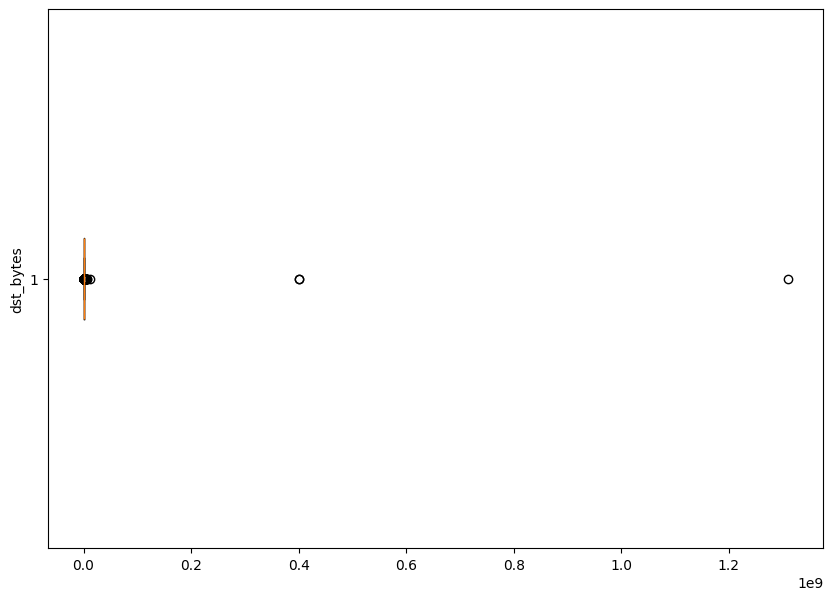

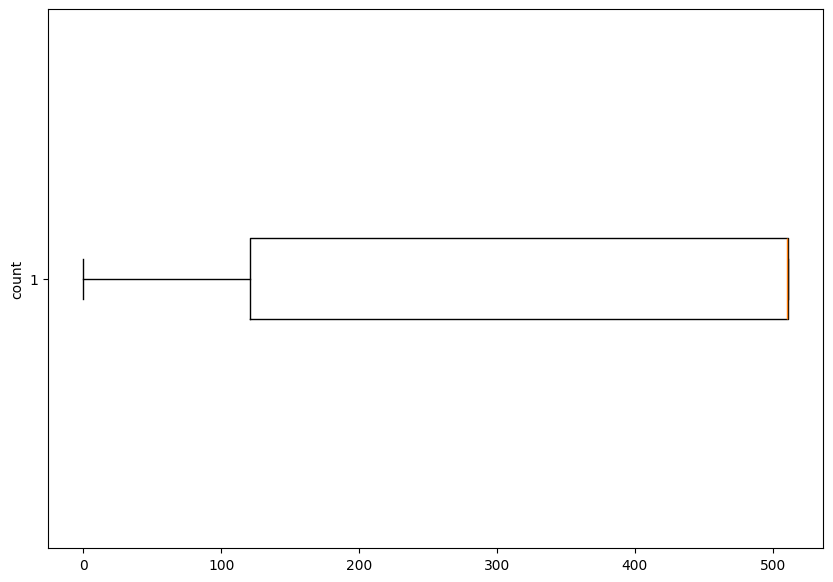

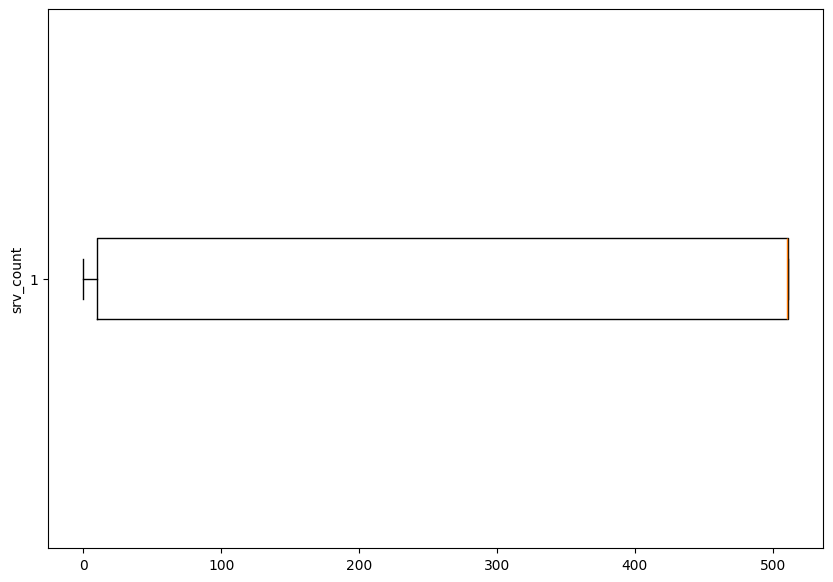

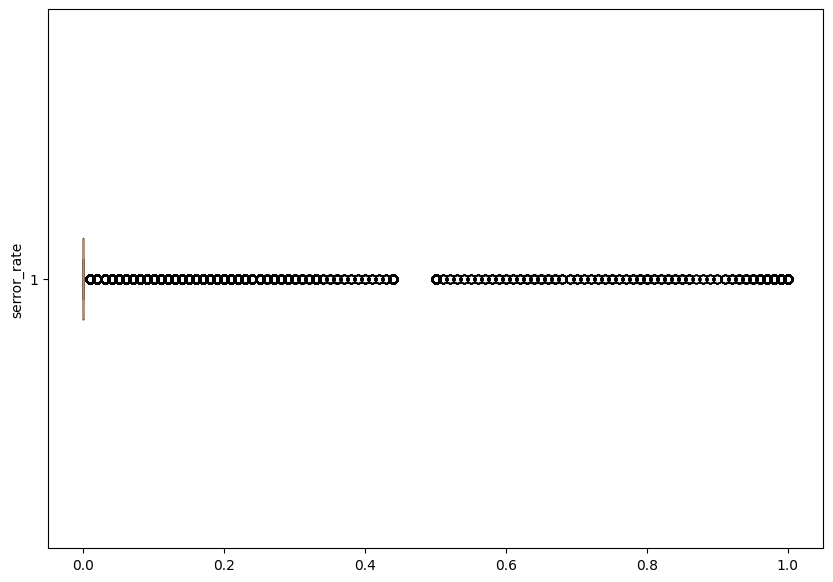

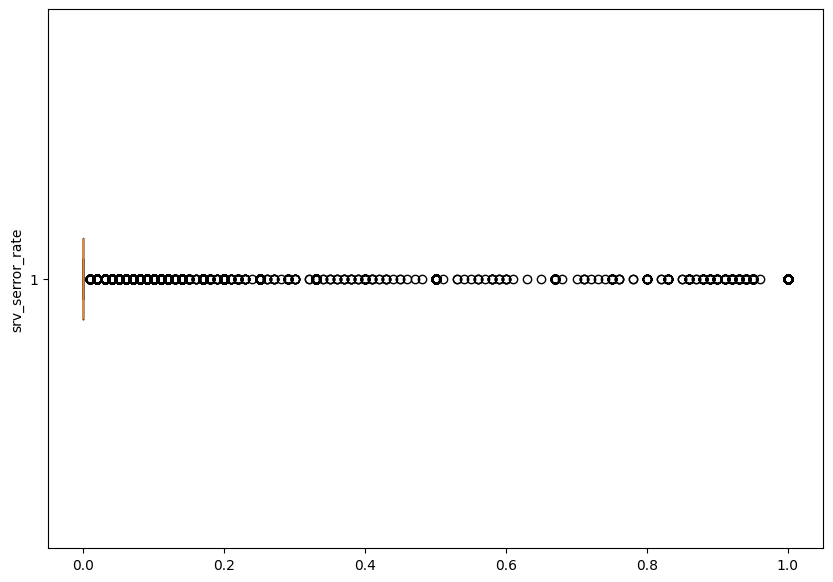

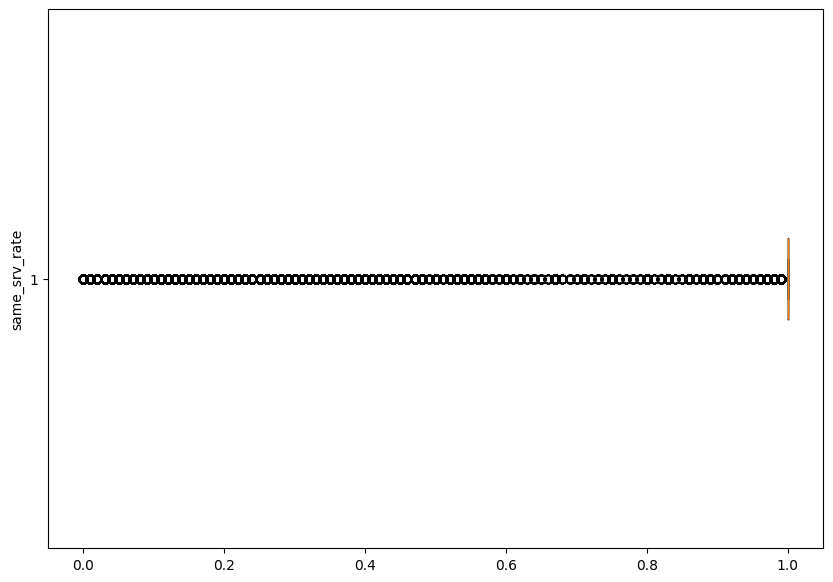

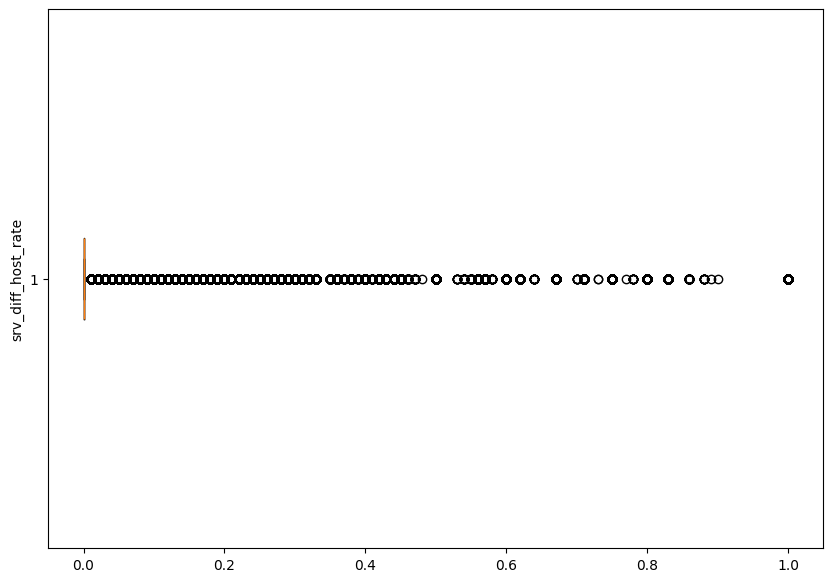

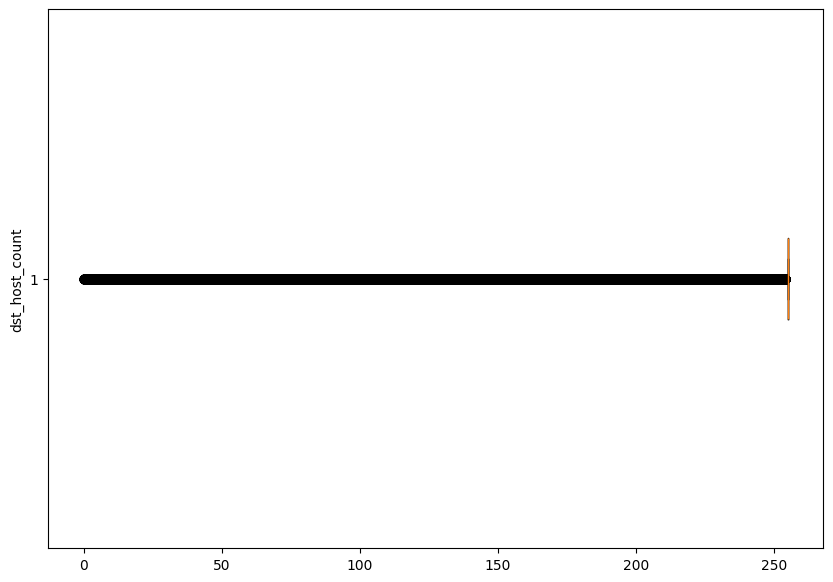

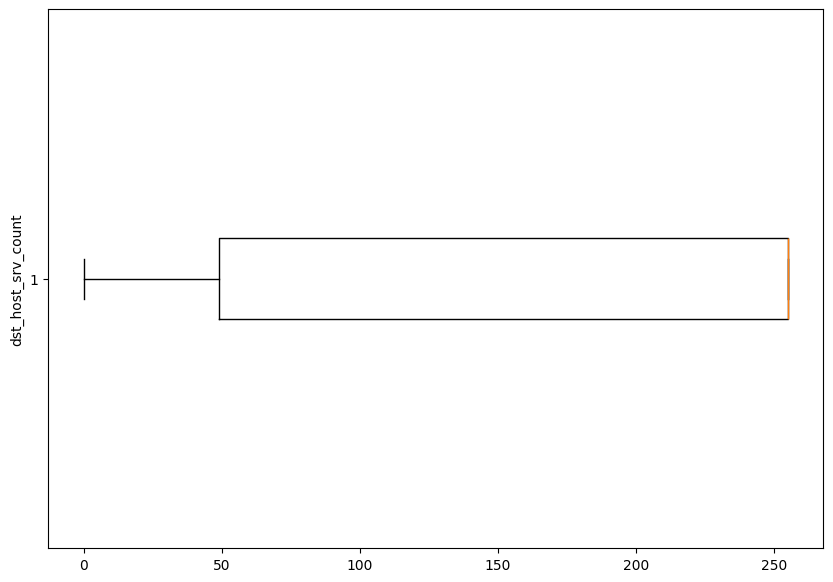

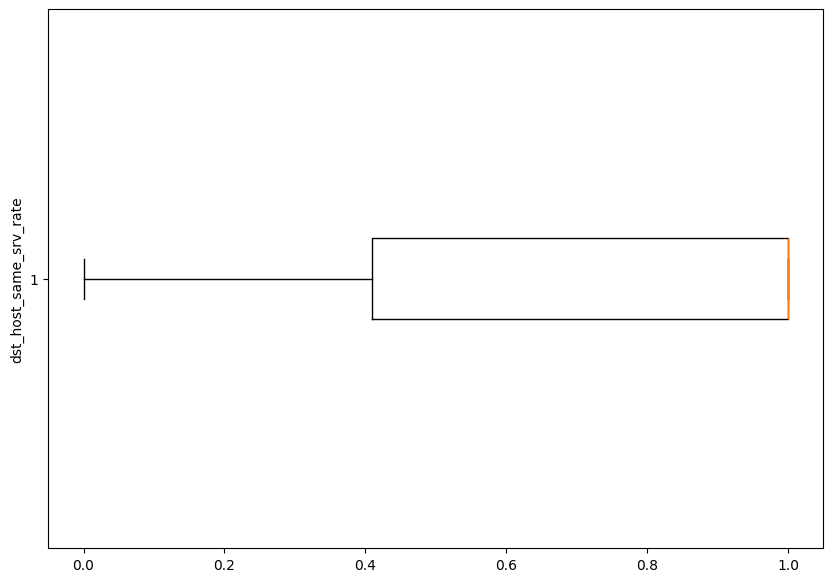

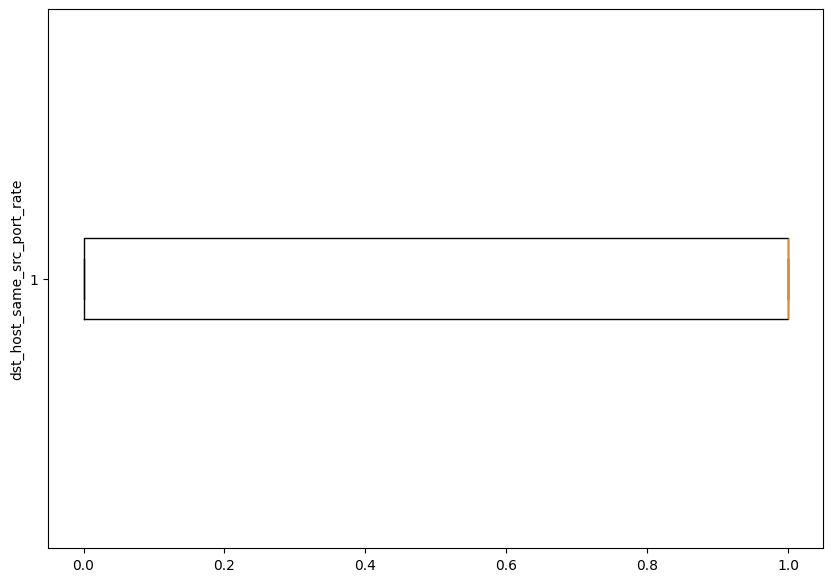

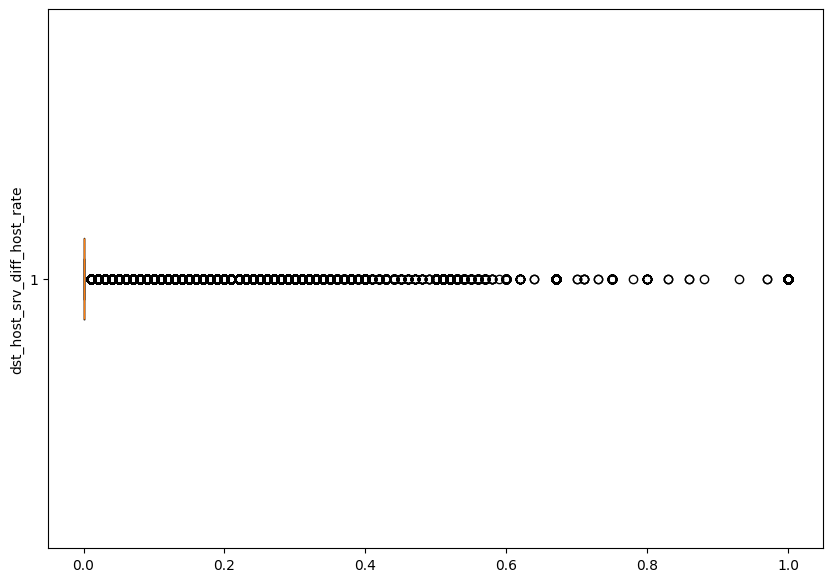

In [13]:
df_boxplots(df_feature_selected_encoded)

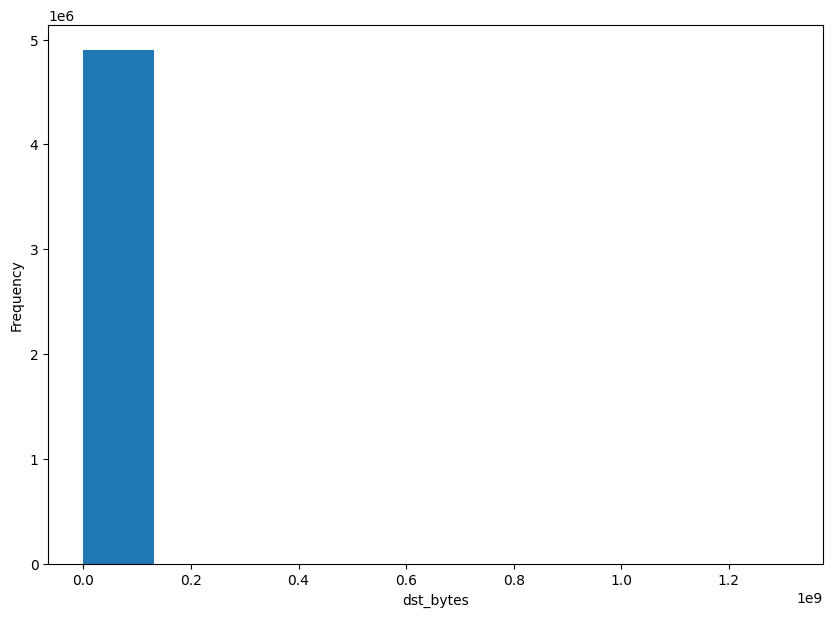

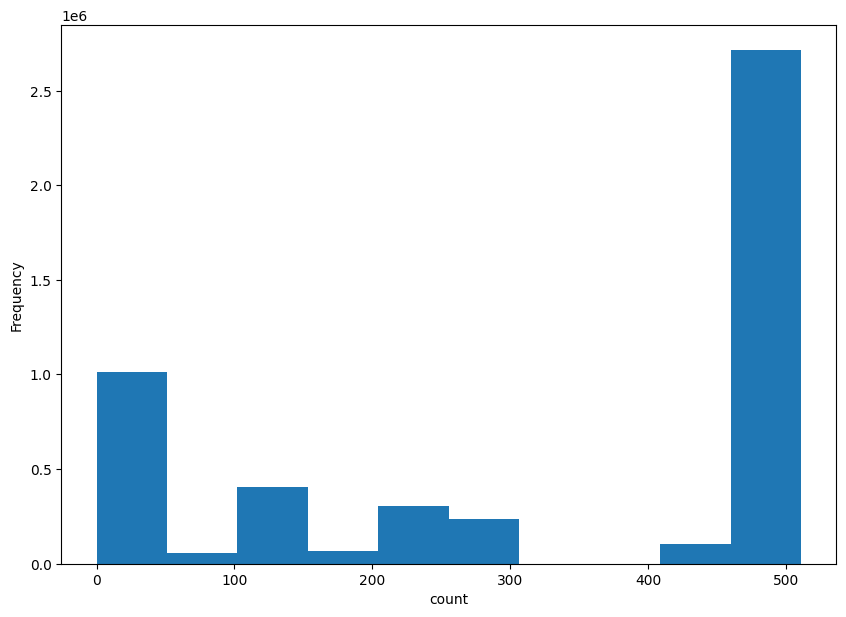

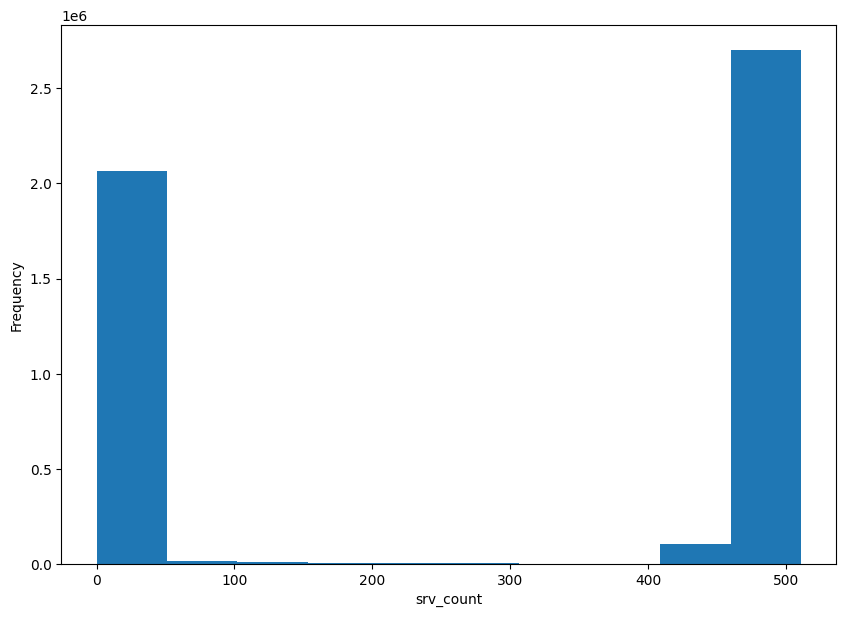

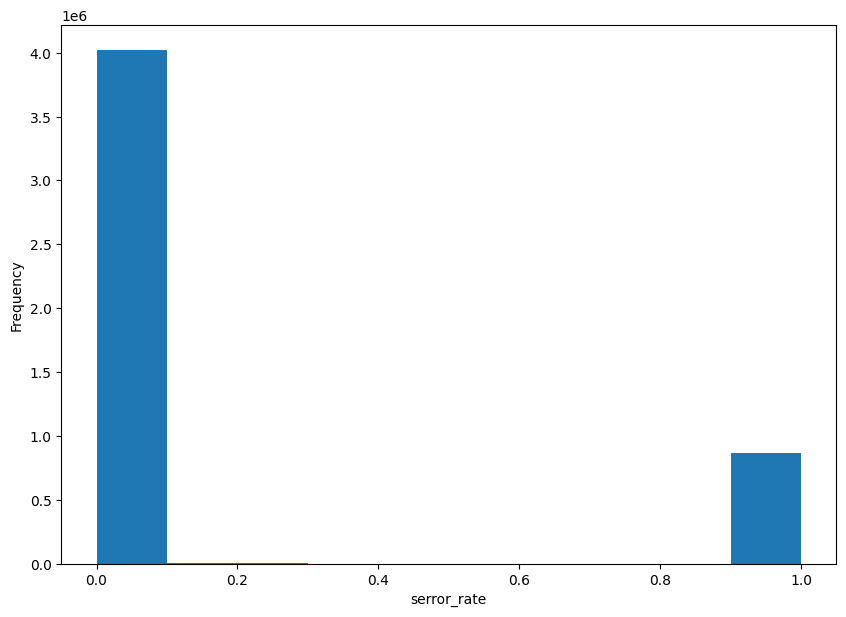

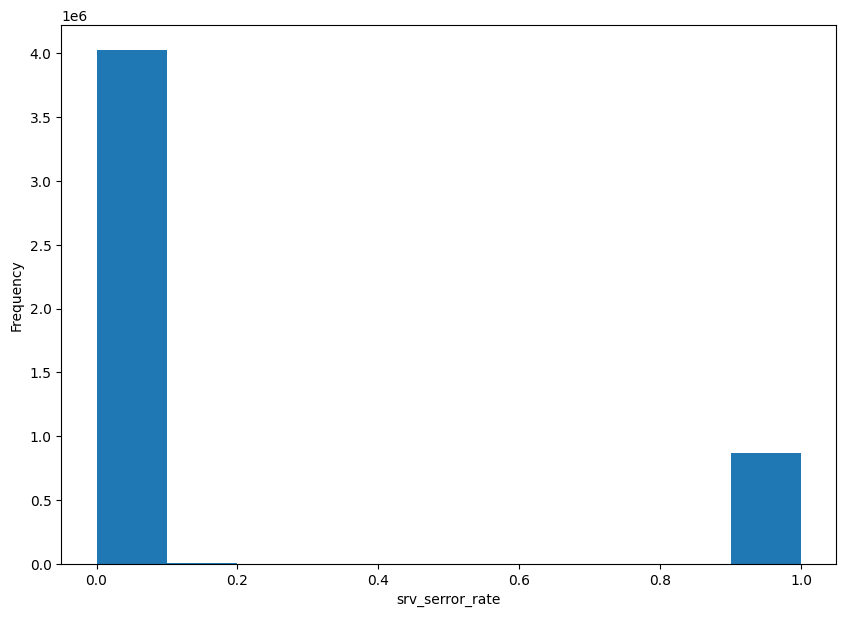

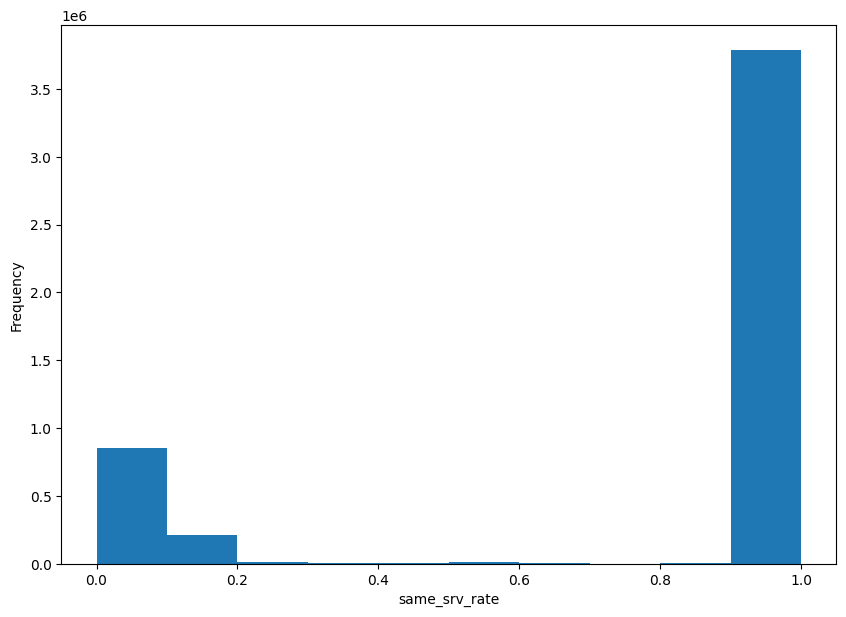

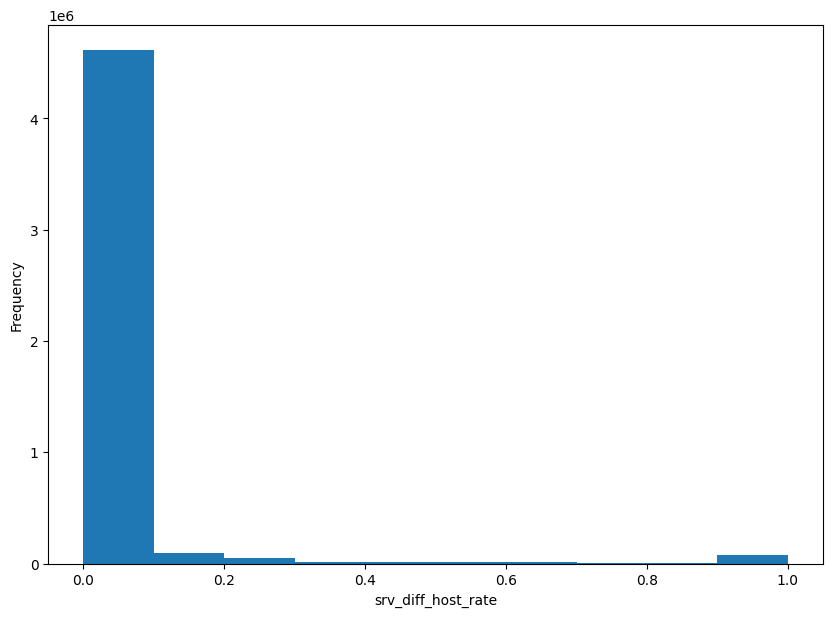

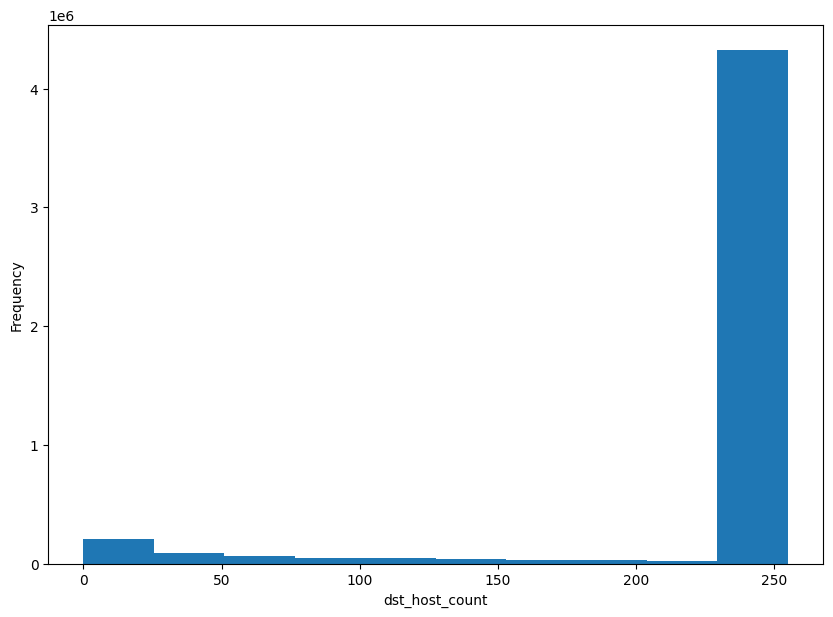

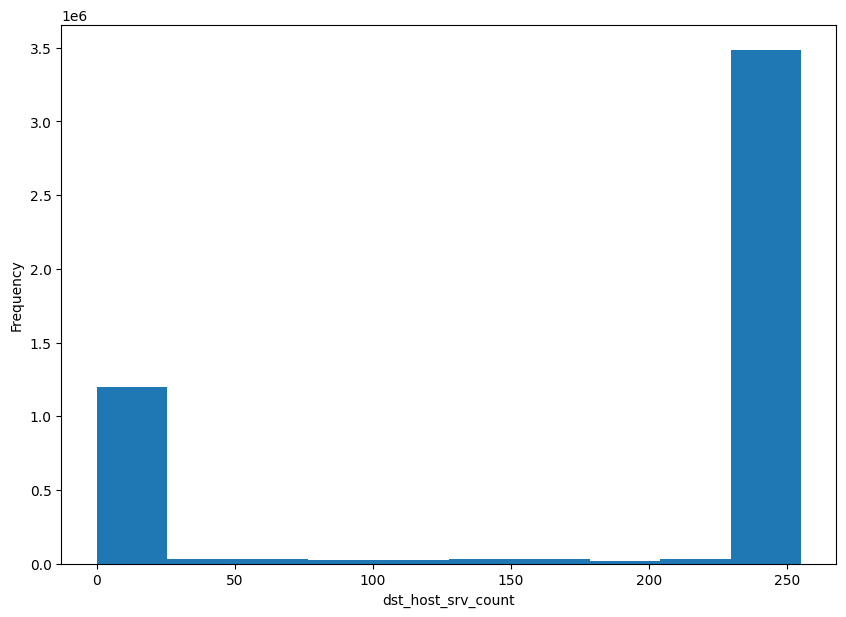

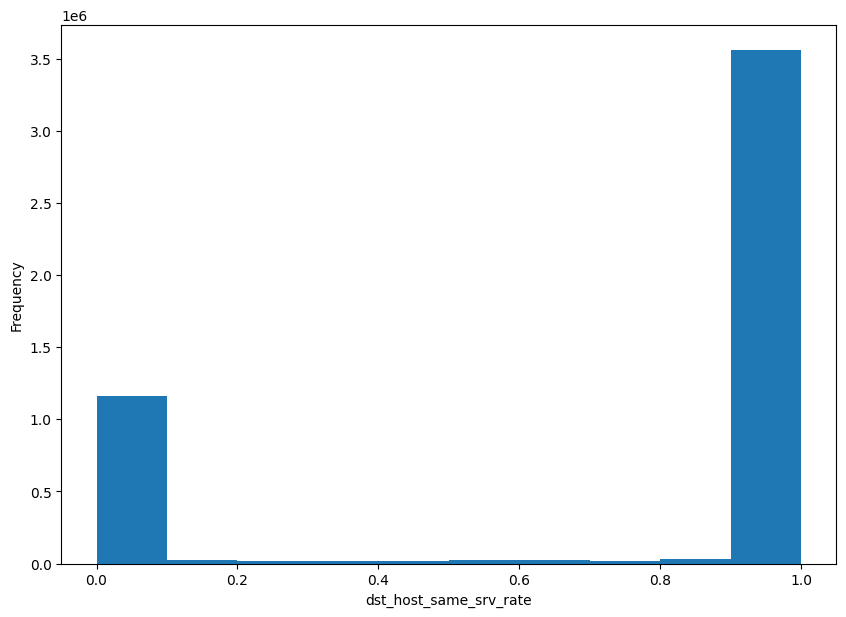

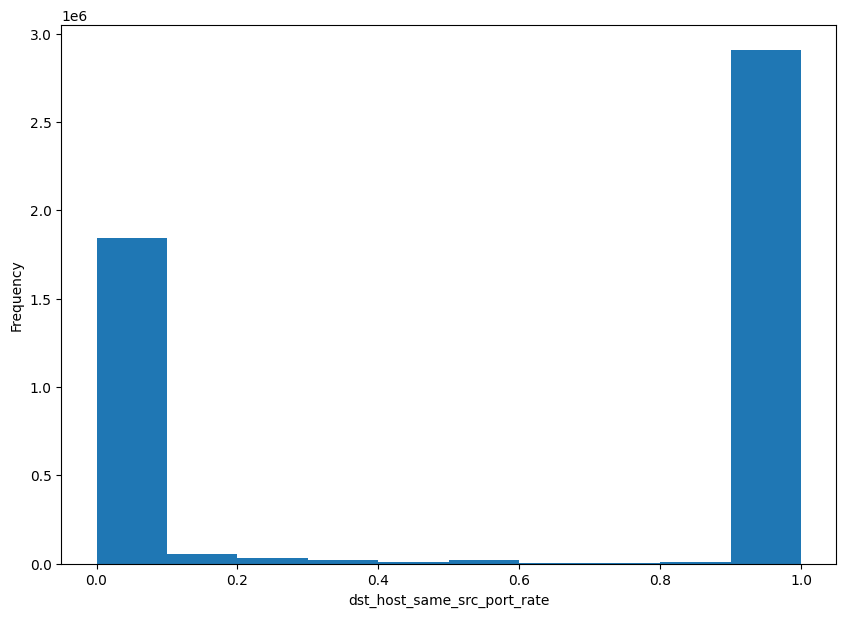

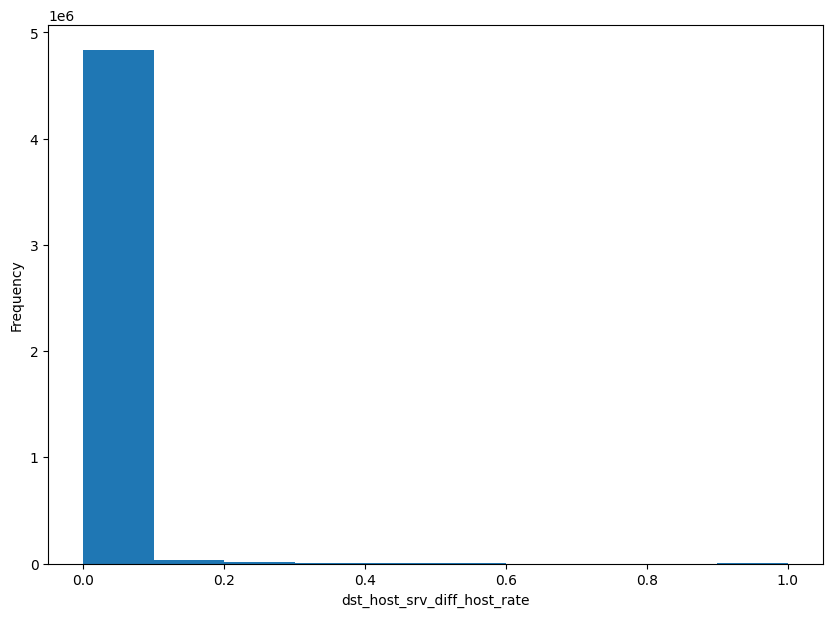

In [14]:
df_hist(df_feature_selected_encoded)

## Removing outliers

In [15]:
df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 1e8]

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
1415575,1,4,400291060,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1
1415576,1,4,400291060,0,2,2,0.0,0.0,1.0,0.0,255,2,0.01,1.0,0.0,1
1417571,1,4,1309937401,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1


In [16]:
df_feature_selected_encoded.shape

(4898431, 16)

In [17]:
df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)
df_feature_selected_encoded.shape

(4898428, 16)

In [18]:
normal = df_feature_selected_encoded.query('label == 0').sample(100000)
attack = df_feature_selected_encoded.query('label == 1').sample(100000)

df_reduced = pd.concat([normal, attack])
df_reduced

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
4891768,1,9,406,1,9,9,0.0,0.0,1.00,0.00,34,255,1.00,0.03,0.01,0
811093,1,9,175,1,19,20,0.0,0.0,1.00,0.10,19,63,1.00,0.05,0.14,0
3418925,2,9,91,0,2,7,0.0,0.0,0.50,0.71,255,240,0.94,0.00,0.00,0
12860,1,9,4758,1,2,15,0.0,0.0,1.00,0.13,63,255,1.00,0.02,0.07,0
827444,1,9,2225,1,6,6,0.0,0.0,1.00,0.00,255,255,1.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258040,0,9,0,0,510,510,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00,1
1903742,0,9,0,0,511,511,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00,1
4309887,0,9,0,0,511,511,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00,1
693427,1,5,0,0,252,6,1.0,1.0,0.02,0.00,255,6,0.02,0.00,0.00,1


## Creating test, train, validation dataframes

In [19]:
labels = df_reduced['label']
features = df_reduced.drop("label", axis=1)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

In [22]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000,)

x_val:(48000, 15)
y_val:(48000,)

x_test:(40000, 15)
y_test:(40000,)


In [23]:
print(Counter(y_train))
print(Counter(y_val))

Counter({0: 56075, 1: 55925})
Counter({1: 24068, 0: 23932})


## Normalizing data

In [24]:
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scale_objects(x_train, scaler)
x_val = scale_objects(x_val, scaler)
x_test = scale_objects(x_test, scaler)

In [25]:
x_train

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
0,0.0,0.9,0.000000,0.0,1.000000,1.000000,0.0,0.0,1.00,0.00,1.000000,1.000000,1.00,1.00,0.00
1,0.5,0.5,0.000000,0.0,0.001961,0.001961,0.5,0.5,1.00,0.00,0.376471,0.560784,0.32,0.03,0.01
2,0.5,0.9,0.000075,1.0,0.021569,0.021569,0.0,0.0,1.00,0.00,1.000000,1.000000,1.00,0.00,0.00
3,0.5,0.9,0.000101,1.0,0.005882,0.005882,0.0,0.0,1.00,0.00,1.000000,1.000000,1.00,0.00,0.00
4,0.5,0.9,0.000439,1.0,0.011765,0.019608,0.0,0.0,1.00,0.27,0.937255,1.000000,1.00,0.00,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111995,0.0,0.9,0.000000,0.0,1.000000,1.000000,0.0,0.0,1.00,0.00,1.000000,1.000000,1.00,1.00,0.00
111996,0.5,0.5,0.000000,0.0,0.488235,0.047059,1.0,1.0,0.10,0.00,1.000000,0.098039,0.10,0.00,0.00
111997,0.5,0.1,0.000000,0.0,0.211765,0.013725,0.0,0.0,0.07,0.00,1.000000,0.031373,0.03,0.00,0.00
111998,1.0,0.9,0.000027,0.0,0.000000,0.000000,0.0,0.0,1.00,0.00,1.000000,0.003922,0.00,0.98,0.00


### Visualise scaled data histograms

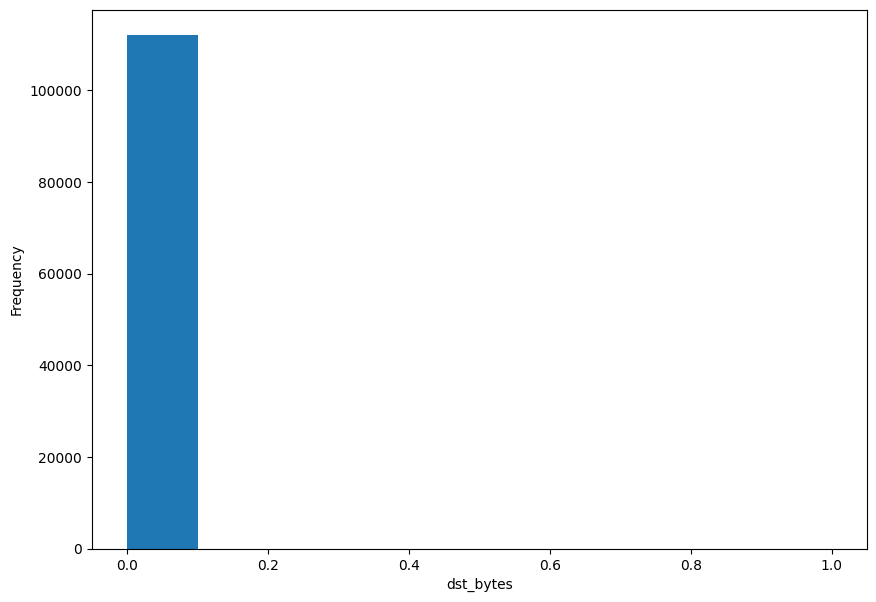

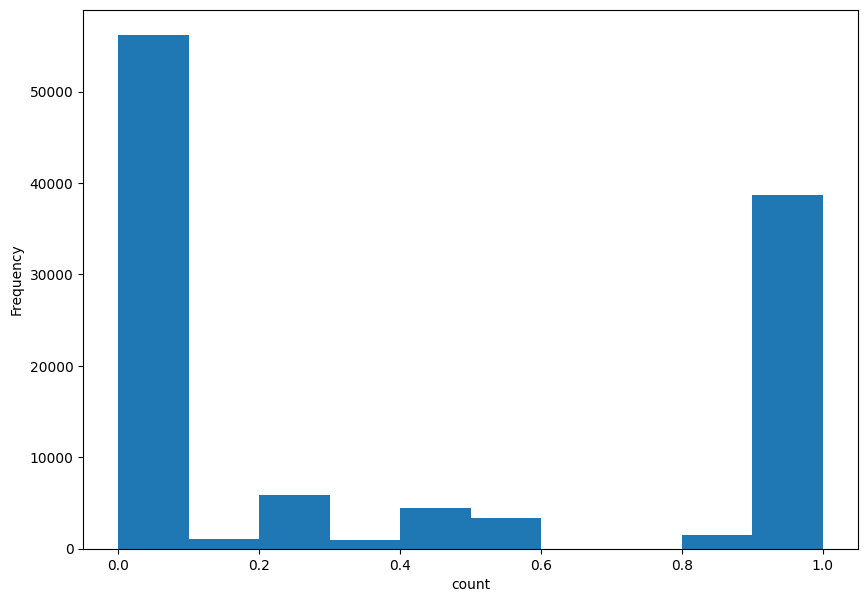

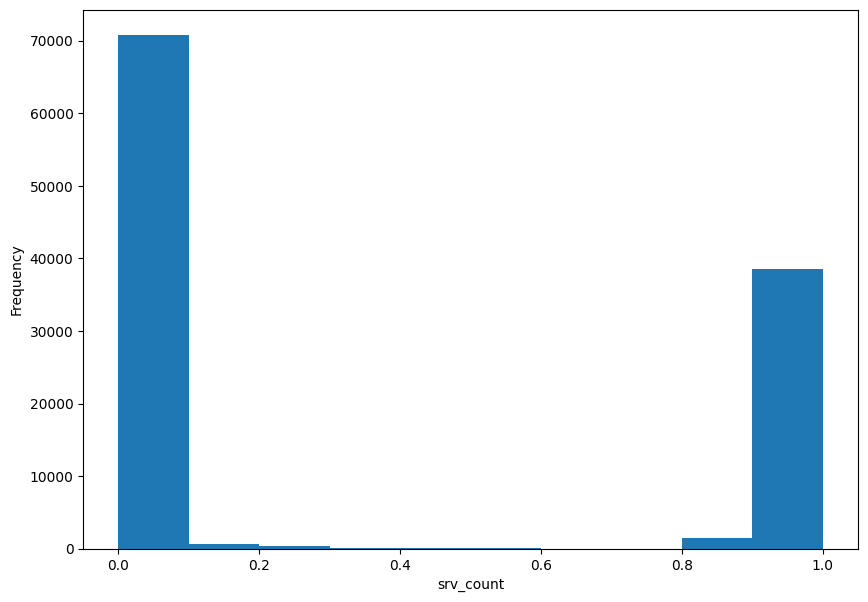

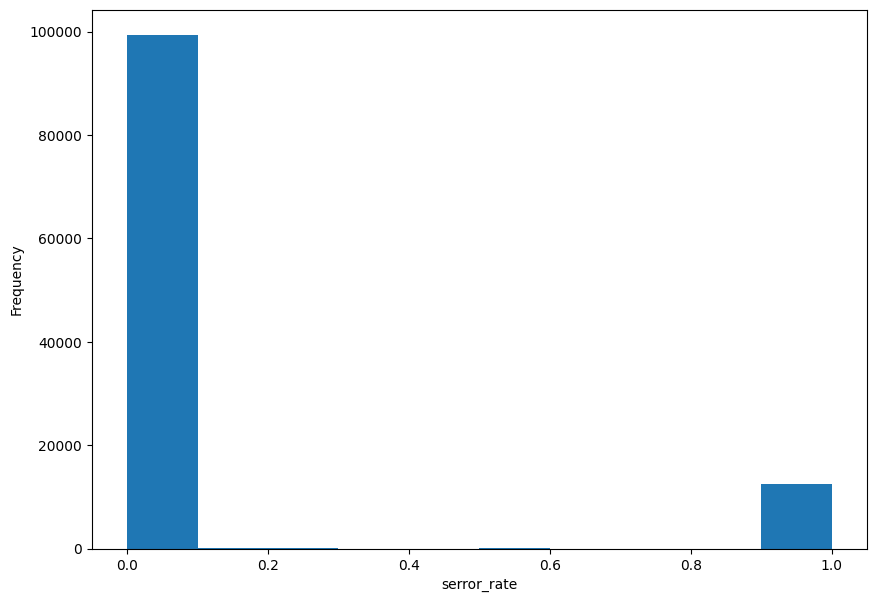

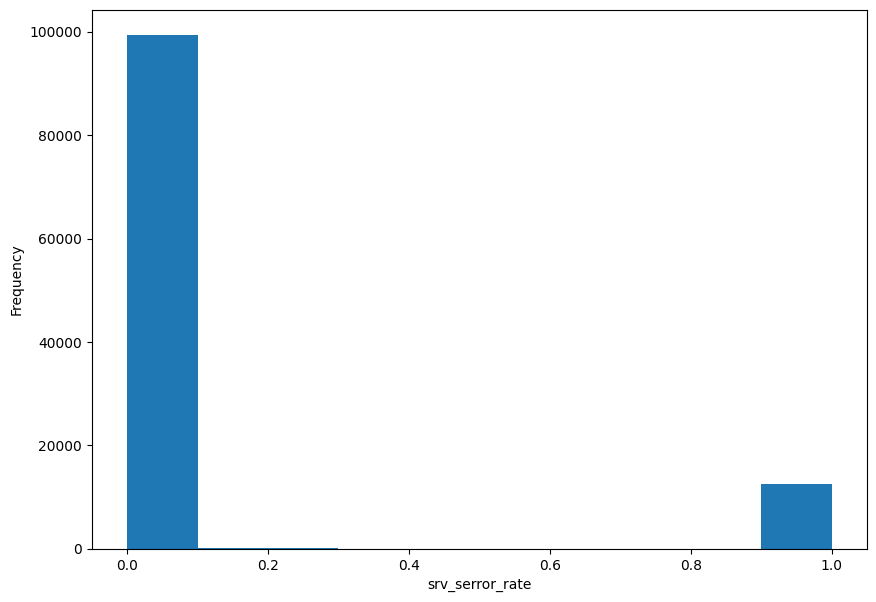

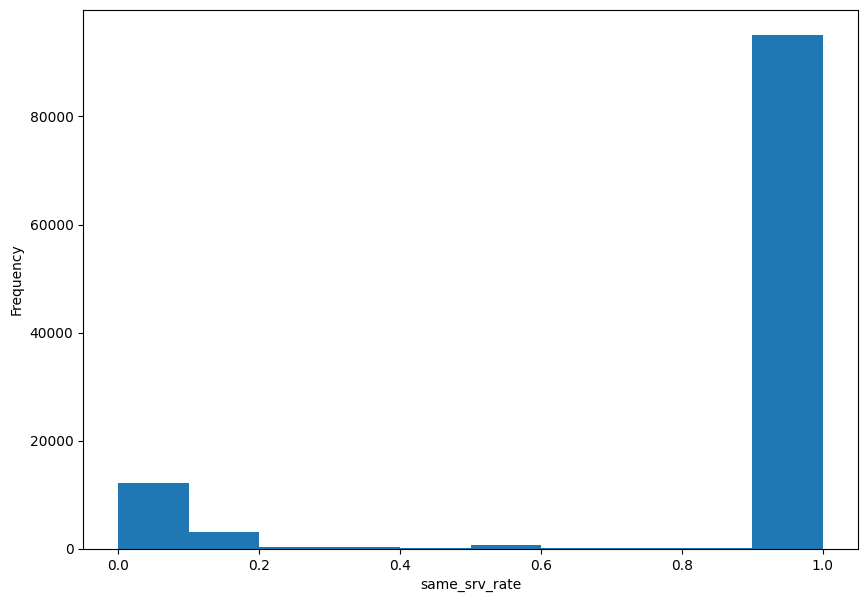

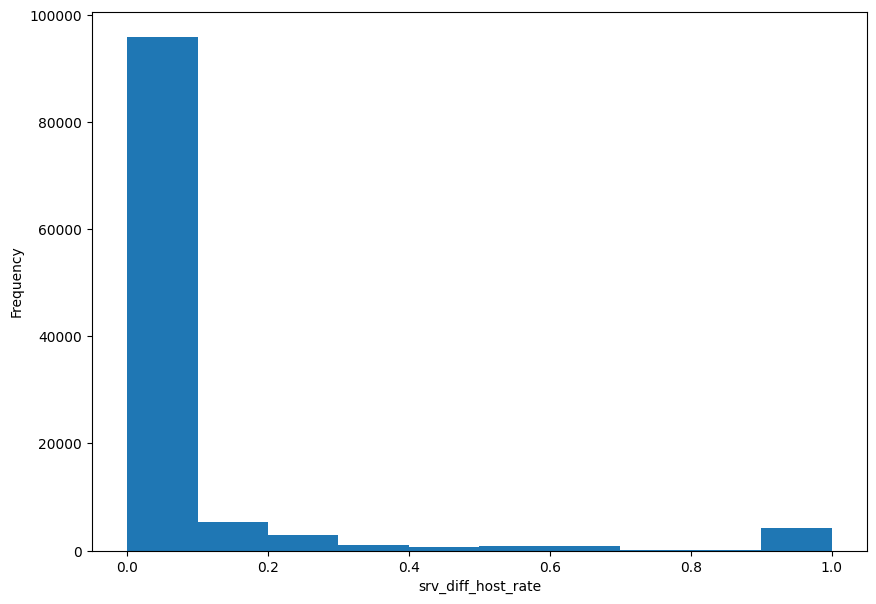

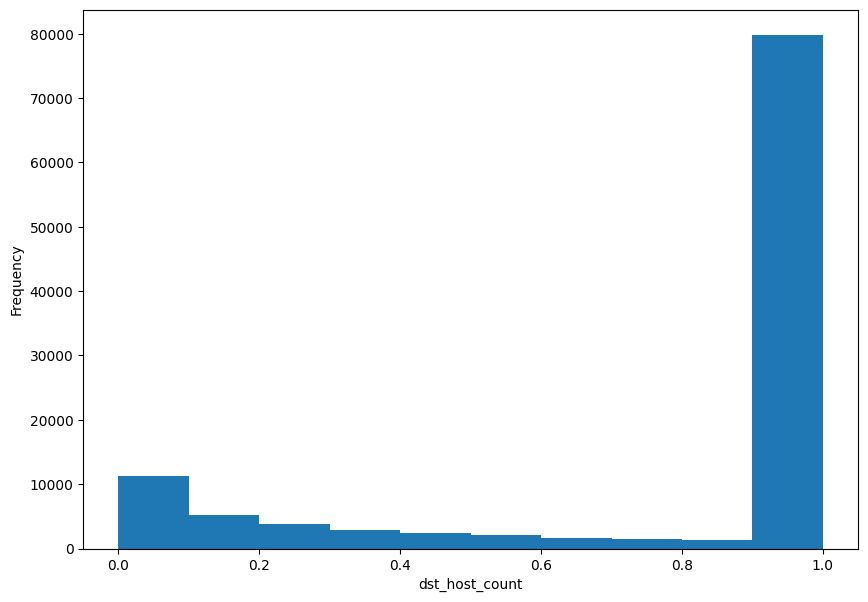

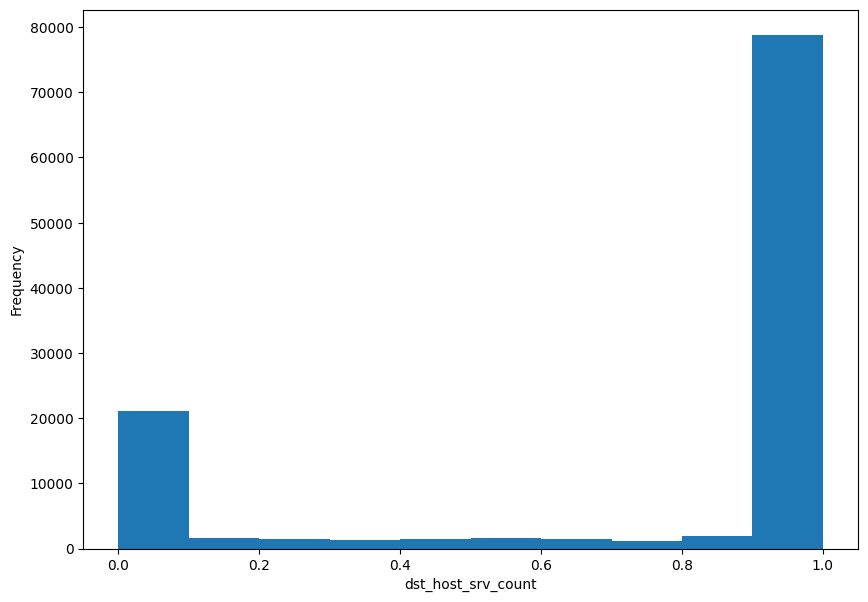

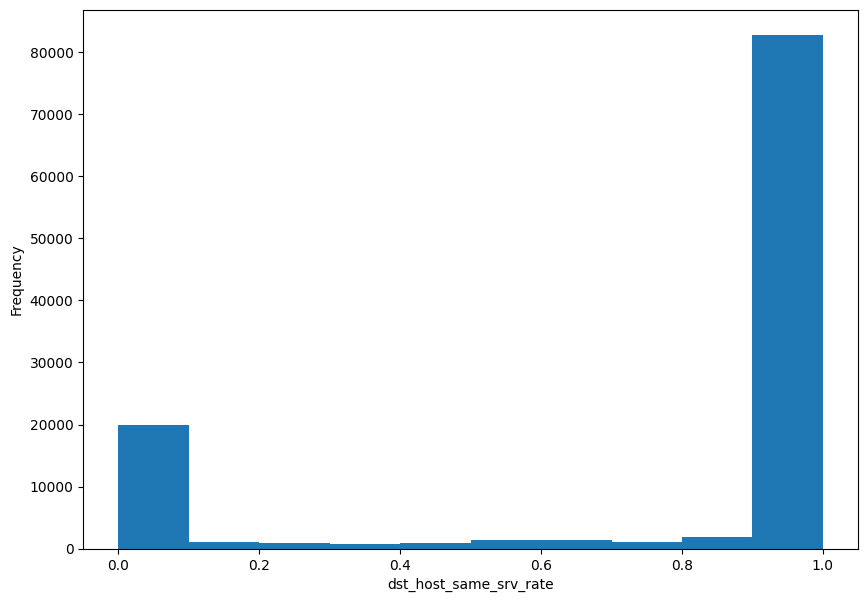

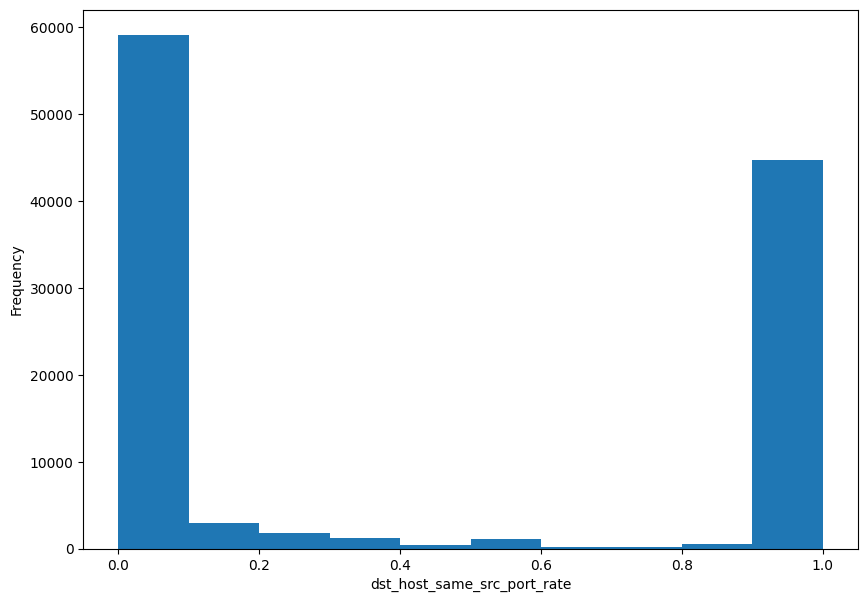

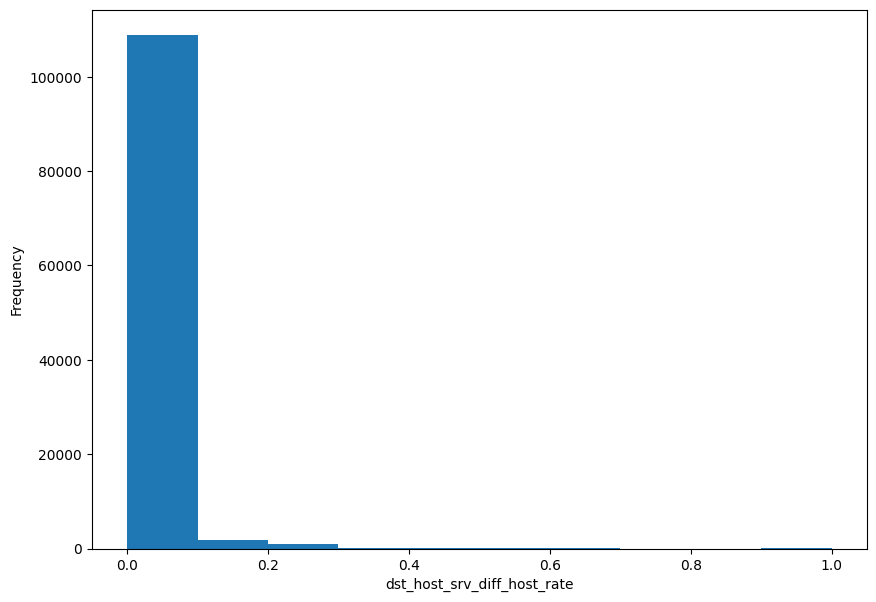

In [26]:
df_hist(x_train)

### Converting output to categorical

In [27]:
y_train =  to_categorical(y_train)
y_test =  to_categorical(y_test)
y_val =  to_categorical(y_val)

In [28]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000, 2)

x_val:(48000, 15)
y_val:(48000, 2)

x_test:(40000, 15)
y_test:(40000, 2)


# Model training

## Simple MLP

In [29]:
# # Load the extension and start TensorBoard
# %reload_ext tensorboard
# %tensorboard --logdir logs/mlp_kdd/

In [30]:
EPOCHS = 30
BATCH_SIZE = 64
UNITS = 32
input_dim = x_train.shape[1]
output_dim = y_train.shape[1]

mlp = tf.keras.models.Sequential([
    
    Input(shape=(input_dim,)),
     
    Dense(UNITS, activation='relu', kernel_initializer = 'glorot_uniform', kernel_regularizer = L2(l2=1e-5)),
    Dense(UNITS, activation='relu', kernel_initializer = 'glorot_uniform', kernel_regularizer = L2(l2=1e-5)),
    
    Dense(output_dim, activation='softmax', kernel_regularizer = L2(l2=1e-5))
    
])

In [31]:
mlp.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
mlp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                512       
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dense_2 (Dense)             (None, 2)                 66        
                                                                 
Total params: 1634 (6.38 KB)
Trainable params: 1634 (6.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(mlp.layers)}_units{UNITS}'

# define our early stopping
es = EarlyStopping(patience=5, 
                   min_delta=1e-3, 
                   monitor='val_loss', 
                   restore_best_weights=True,
                   verbose=1)

rLROnP = ReduceLROnPlateau(patience=5, 
                           min_delta=1e-3, 
                           factor=0.05, 
                           mode="auto", 
                           verbose=1, 
                           cooldown=0, 
                           min_lr=0.0)


save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_unsw_best_weights.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/mlp_kdd/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [es, rLROnP, save_model, tensorboard]

In [33]:
history = mlp.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb)

Epoch 1/30


2024-03-29 21:22:06.637899: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f997c005070 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2024-03-29 21:22:06.638176: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2024-03-29 21:22:07.136840: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  21/1750 [..............................] - ETA: 9s - loss: 0.5733 - accuracy: 0.8631    

2024-03-29 21:22:08.740173: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-03-29 21:22:08.761363: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-29 21:22:08.762108: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-29 21:22:08.762451: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-29 21:22:08.807660: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-29 21:22:08.812318: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-29 21:22:08.818385: E ./tensorflow/compiler/xla/stream_executor/stream_executor_int

1750/1750 [==============================] - 30s 7ms/step - loss: 0.0257 - accuracy: 0.9959 - val_loss: 0.0079 - val_accuracy: 0.9987 - lr: 0.0010


/mnt/c/Users/David/OneDrive - Technical University of Cluj-Napoca/Desktop/David/university/ETTI/Thesis/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/30
1750/1750 [==============================] - 11s 6ms/step - loss: 0.0078 - accuracy: 0.9987 - val_loss: 0.0078 - val_accuracy: 0.9986 - lr: 0.0010
Epoch 3/30
1750/1750 [==============================] - 11s 6ms/step - loss: 0.0072 - accuracy: 0.9987 - val_loss: 0.0072 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 4/30
1750/1750 [==============================] - 12s 7ms/step - loss: 0.0069 - accuracy: 0.9988 - val_loss: 0.0069 - val_accuracy: 0.9988 - lr: 0.0010
Epoch 5/30
1750/1750 [==============================] - 11s 6ms/step - loss: 0.0066 - accuracy: 0.9989 - val_loss: 0.0067 - val_accuracy: 0.9988 - lr: 0.0010
Epoch 6/30
1750/1750 [==============================] - 12s 7ms/step - loss: 0.0064 - accuracy: 0.9988 - val_loss: 0.0074 - val_accuracy: 0.9990 - lr: 0.0010
Epoch 7/30
1750/1750 [==============================] - 11s 6ms/step - loss: 0.0063 - accuracy: 0.9988 - val_loss: 0.0090 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 8/30
1750/1750 [==============================

# Evaluating model

In [34]:
mlp.evaluate(x_test, y_test)

1250/1250 [==============================] - 3s 2ms/step - loss: 0.0073 - accuracy: 0.9988


[0.007304213009774685, 0.9987750053405762]

In [35]:
preds = mlp.predict(x_test)

# One hot to the original label encodings
y_true = y_test.argmax(axis=1)

# Derive the label predictions from the probability scores
y_preds = preds.argmax(axis=1)

# Compute precision, recall, f1 scores
precision = precision_score(y_true, y_preds)
recall = recall_score(y_true, y_preds)
f1_measure = f1_score(y_true, y_preds)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Measure: {f1_measure}")

1250/1250 [==============================] - 3s 2ms/step
Precision: 0.9997495993589743
Recall: 0.9978007697305943
F1-Measure: 0.9987742338961851


In [36]:
roc_auc_score(y_true, y_preds)

0.9987753410999792

Text(50.722222222222214, 0.5, 'True Label')

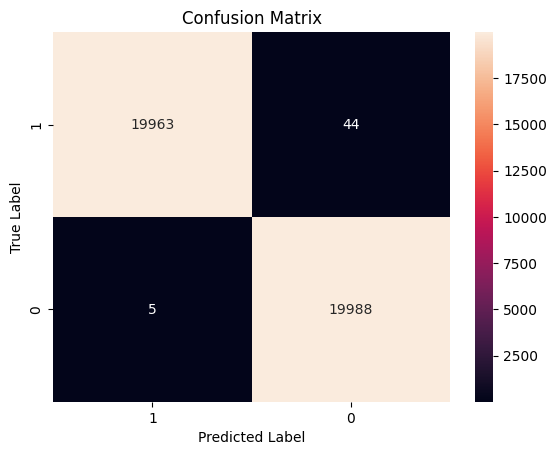

In [37]:
cm = confusion_matrix(y_true, y_preds)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [38]:
tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Negative:", fn)
print("True Positive:", tp)
print("False Positive:", fp)

True Negative: 19988
False Negative: 44
True Positive: 19963
False Positive: 5
